# Santiago Marin Yepes

La idea principal del algoritmo es la siguiente:

Supongamos que tenemos un conjunto de datos en el que sabemos que existen varios tipos de clases o especies mezcladas. Nuestro objetivo es identificar las características propias de cada una de estas especies, de tal forma que posteriormente podamos predecir, a partir de nuevos datos, a qué clase o especie pertenece cada observación.

En nuestro caso, podemos suponer que tenemos una mezcla de dos tipos diferentes de átomos. Luego dejamos que el sistema evolucione hasta alcanzar un estado estacionario y tomamos una imagen de su estado final. Como resultado, obtenemos una malla que contiene las posiciones de los átomos y el tipo o especie correspondiente a cada uno de ellos.

Luego, la idea es dibujar una frontera que divida las dos especies de átomos en dos regiones. De esta manera, podemos realizar predicciones sobre nuevos datos basándonos en la región en la que caiga cada nuevo punto. Así, es posible determinar a qué tipo o especie pertenece un nuevo átomo según su posición dentro de la malla.

Para tener una forma fiable de evaluar nuestro modelo, no utilizaremos todos los datos al momento de construir la frontera de decisión. Posteriormente, evaluaremos su rendimiento observando cuántos de los datos que no fueron utilizados durante el entrenamiento son clasificados correctamente.

Tarea

Voy a dividir mi solución en dos partes. La primera será un intento por fuerza bruta, en el que utilizaré una frontera trazada manualmente y probaré todo el algoritmo.

Posteriormente, resolveré el mismo problema utilizando la implementación de scikit-learn como una caja negra.

# Primera solución

In [136]:
# @title Librerías

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    learning_curve,
    ShuffleSplit
)

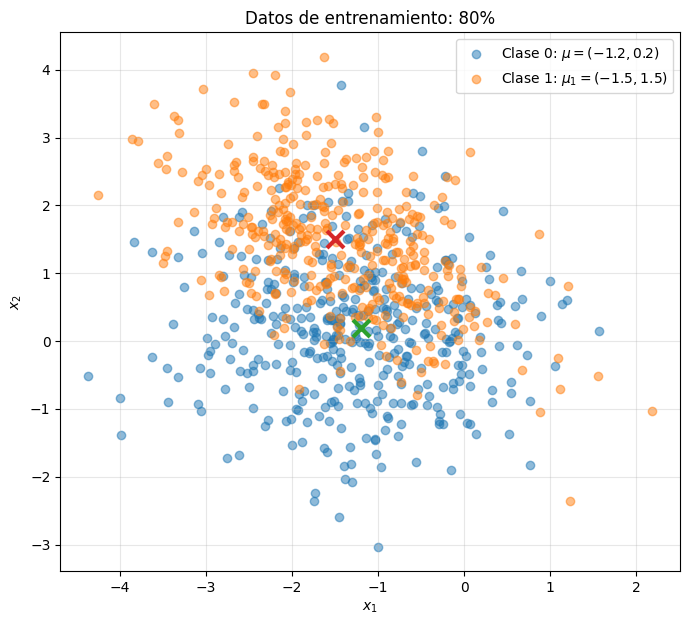

In [137]:
# @title


# -----------------------------
# Parámetros de las distribuciones
# -----------------------------

mu = [-1.2, 0.2]

mu1 = [-1.5, 1.5]

cov = [
    [1.0, 0.0],
    [0.0, 1.0]
]

cov1 = [
    [1.0, -0.5],
    [-0.5, 1.0]
]

# -----------------------------
# Crear las distribuciones
# -----------------------------

rv = multivariate_normal(mean=mu, cov=cov)

rv1 = multivariate_normal(mean=mu1, cov=cov1)

# -----------------------------
# Generar puntos aleatorios
# -----------------------------

np.random.seed(123)

datos0 = rv.rvs(size=500)
datos1 = rv1.rvs(size=500)

# Unir las dos distribuciones
datos = np.concatenate((datos0, datos1), axis=0)

# -----------------------------
# Identificadores de clase
# -----------------------------

# Clase 0 para datos0
# Clase 1 para datos1
identificador = np.concatenate((
    np.zeros(len(datos0), dtype=int),
    np.ones(len(datos1), dtype=int)
))

# -----------------------------
# División de los datos
# -----------------------------

N = len(datos)

# Índices aleatorios sin repetición
indices = np.random.permutation(N)

# 80% de los datos para entrenamiento
n_train = int(0.80 * N)

# Separar índices
indices_train = indices[:n_train]
indices_test = indices[n_train:]

# -----------------------------
# Construir los conjuntos
# -----------------------------

# 80% para entrenamiento
datos_train = datos[indices_train]

# 20% para prueba
datos_test = datos[indices_test]

# -----------------------------
# Identificadores de cada conjunto
# -----------------------------

identificador_train = identificador[indices_train]

identificador_test = identificador[indices_test]

# -----------------------------
# Separar clases de entrenamiento
# -----------------------------

train_clase0 = datos_train[identificador_train == 0]

train_clase1 = datos_train[identificador_train == 1]

# -----------------------------
# Graficar solo entrenamiento
# -----------------------------

plt.figure(figsize=(8, 7))

plt.scatter(
    train_clase0[:, 0],
    train_clase0[:, 1],
    alpha=0.5,
    label=r"Clase 0: $\mu=(-1.2,0.2)$"
)

plt.scatter(
    train_clase1[:, 0],
    train_clase1[:, 1],
    alpha=0.5,
    label=r"Clase 1: $\mu_1=(-1.5,1.5)$"
)

# Graficar los centros
plt.scatter(
    mu[0],
    mu[1],
    marker="x",
    s=150,
    linewidths=3
)

plt.scatter(
    mu1[0],
    mu1[1],
    marker="x",
    s=150,
    linewidths=3
)


plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")

plt.title("Datos de entrenamiento: 80%")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


In [138]:
def frontera(x, y1, b):

    y_frontera = b

    diferencia = y1 - y_frontera

    if diferencia < 0:
        return 0
    else:
        return 1

In [139]:
# @title

# ============================================================
# Función de frontera
# ============================================================

def frontera(x, y1, b):

    diferencia = y1 - b

    if diferencia < 0:
        return 0
    else:
        return 1


# ============================================================
# 1. ENTRENAMIENTO
# Probar diferentes valores de b
# ============================================================

Y_train = identificador_train

# Valores de b a probar
valores_b = np.linspace(-1.0, 2.0, 100)

# Variables para guardar el mejor resultado
mejor_b = None

min_errores = len(Y_train) + 1
max_aciertos = 0
mejor_calificacion = 0


for b in valores_b:

    Y_pred = []

    # Clasificar los datos de entrenamiento
    for dato in datos_train:

        x = dato[0]
        y1 = dato[1]

        clase = frontera(x, y1, b)

        Y_pred.append(clase)


    # --------------------------------------------------------
    # Contar aciertos
    # --------------------------------------------------------

    aciertos = 0

    for i in range(len(Y_train)):

        if Y_pred[i] == Y_train[i]:
            aciertos += 1


    # --------------------------------------------------------
    # Calcular errores y calificación
    # --------------------------------------------------------

    errores = len(Y_train) - aciertos

    calificacion = aciertos / len(Y_train)


    # --------------------------------------------------------
    # Escoger el mejor b
    # --------------------------------------------------------

    if errores < min_errores:

        min_errores = errores
        max_aciertos = aciertos
        mejor_calificacion = calificacion
        mejor_b = b


# ============================================================
# Resultados del entrenamiento
# ============================================================

print("RESULTADOS DEL ENTRENAMIENTO")
print("----------------------------")

print("Mejor valor de b:", mejor_b)

print("Aciertos:", max_aciertos)

print("Errores:", min_errores)

print(
    "Calificación de entrenamiento:",
    mejor_calificacion * 100,
    "%"
)


# ============================================================
# 2. PRUEBA DEL b GANADOR
# ============================================================

Y_test = identificador_test

Y_pred_test = []


for dato in datos_test:

    x = dato[0]
    y1 = dato[1]

    clase = frontera(
        x,
        y1,
        mejor_b
    )

    Y_pred_test.append(clase)


# ============================================================
# Contar aciertos y errores en prueba
# ============================================================

aciertos_test = 0


for i in range(len(Y_test)):

    if Y_pred_test[i] == Y_test[i]:
        aciertos_test += 1


errores_test = len(Y_test) - aciertos_test

calificacion_test = (
    aciertos_test / len(Y_test)
)


# ============================================================
# Resultados finales
# ============================================================

print()
print("RESULTADOS DE PRUEBA")
print("--------------------")

print("b utilizado:", mejor_b)

print("Aciertos:", aciertos_test)

print("Errores:", errores_test)

print(
    "Calificación final de capacidad de predicción:",
    calificacion_test * 100,
    "%"
)

RESULTADOS DEL ENTRENAMIENTO
----------------------------
Mejor valor de b: 0.6363636363636365
Aciertos: 608
Errores: 192
Calificación de entrenamiento: 76.0 %

RESULTADOS DE PRUEBA
--------------------
b utilizado: 0.6363636363636365
Aciertos: 150
Errores: 50
Calificación final de capacidad de predicción: 75.0 %


# Entrenamiento del modelo

Para entrenar el modelo se dividió el conjunto de datos en dos partes:

- **80% de los datos** se utilizaron para entrenamiento.
- **20% de los datos** se reservaron para evaluar posteriormente la capacidad de predicción del modelo.

Durante el entrenamiento se consideró una frontera de decisión horizontal de la forma

$$
y=b
$$

donde $b$ es el único parámetro que debe aprender el modelo.

La regla de clasificación utilizada fue

$$
y_i-b<0
\quad \Rightarrow \quad
\hat{y}_i=0
$$

mientras que

$$
y_i-b\geq0
\quad \Rightarrow \quad
\hat{y}_i=1.
$$

Para encontrar el valor óptimo de $b$, se probaron diferentes valores dentro de un intervalo determinado. Para cada valor de $b$, todos los datos de entrenamiento fueron clasificados utilizando la frontera correspondiente.

Posteriormente, las predicciones obtenidas se compararon con las etiquetas reales de los datos de entrenamiento y se contó el número de clasificaciones correctas e incorrectas.

El error de entrenamiento para cada valor de $b$ se definió como

$$
N_{\text{error}}(b)
=
N_{\text{train}}
-
N_{\text{aciertos}}(b).
$$

Por tanto, el valor seleccionado fue aquel que produjo el menor número de errores:

$$
b^{*}
=
\underset{b}{\arg\min}
\;N_{\text{error}}(b).
$$

Esto es equivalente a seleccionar el valor de $b$ que produce el mayor número de aciertos,

$$
b^{*}
=
\underset{b}{\arg\max}
\;N_{\text{aciertos}}(b).
$$

De esta manera, el entrenamiento consiste en buscar por fuerza bruta la posición de la frontera horizontal que mejor separa las dos clases utilizando únicamente los datos de entrenamiento.


# Parte 2 de la tarea con la libreria

Mejor C: 5.455594781168514
Mejor gamma: 0.18873918221350977
Accuracy promedio de validación: 0.7575000000000001

Accuracy entrenamiento: 0.759
Accuracy prueba: 0.750
Diferencia: 0.009


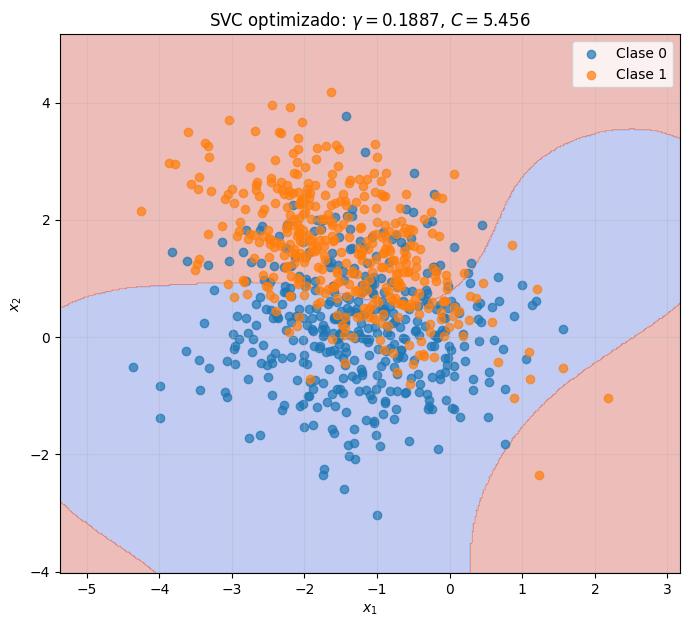

In [140]:
# @title



# ============================================================
# 1. Pipeline: normalización + SVC
# ============================================================

modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])


# ============================================================
# 2. Valores de C y gamma que queremos probar
# ============================================================

parametros = {

    "svc__C": np.logspace(-2, 2, 20),

    "svc__gamma": np.logspace(-4, 1, 30)
}


# ============================================================
# 3. Validación cruzada estratificada
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)


# ============================================================
# 4. Buscar la mejor combinación de C y gamma
# ============================================================

busqueda = GridSearchCV(
    estimator=modelo,
    param_grid=parametros,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)


# IMPORTANTE:
# solamente usamos los datos de entrenamiento
busqueda.fit(
    datos_train,
    identificador_train
)


# ============================================================
# 5. Modelo seleccionado
# ============================================================

clf = busqueda.best_estimator_

mejor_C = busqueda.best_params_["svc__C"]
mejor_gamma = busqueda.best_params_["svc__gamma"]


print("Mejor C:", mejor_C)
print("Mejor gamma:", mejor_gamma)

print(
    "Accuracy promedio de validación:",
    busqueda.best_score_
)


# ============================================================
# 6. Accuracy de entrenamiento y prueba
# ============================================================

accuracy_train = clf.score(
    datos_train,
    identificador_train
)

accuracy_test = clf.score(
    datos_test,
    identificador_test
)


print()
print(
    f"Accuracy entrenamiento: {accuracy_train:.3f}"
)

print(
    f"Accuracy prueba: {accuracy_test:.3f}"
)

print(
    f"Diferencia: {accuracy_train - accuracy_test:.3f}"
)


# ============================================================
# 7. Crear la malla
# ============================================================

def make_meshgrid(X0, X1, h=0.02):

    x_min = X0.min() - 1
    x_max = X0.max() + 1

    y_min = X1.min() - 1
    y_max = X1.max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    return xx, yy


# ============================================================
# 8. Función para dibujar las regiones
# ============================================================

def plot_contours(ax, clf, xx, yy, **params):

    puntos = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    Z = clf.predict(puntos)

    Z = Z.reshape(xx.shape)

    return ax.contourf(
        xx,
        yy,
        Z,
        **params
    )


# ============================================================
# 9. Crear malla usando los datos de entrenamiento
# ============================================================

X0 = datos_train[:, 0]
X1 = datos_train[:, 1]

xx, yy = make_meshgrid(
    X0,
    X1
)


# ============================================================
# 10. Graficar frontera
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)


plot_contours(
    ax,
    clf,
    xx,
    yy,
    cmap=plt.cm.coolwarm,
    alpha=0.35
)


# Clase 0
plt.scatter(
    datos_train[
        identificador_train == 0, 0
    ],
    datos_train[
        identificador_train == 0, 1
    ],
    alpha=0.7,
    label="Clase 0"
)


# Clase 1
plt.scatter(
    datos_train[
        identificador_train == 1, 0
    ],
    datos_train[
        identificador_train == 1, 1
    ],
    alpha=0.7,
    label="Clase 1"
)


plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")

plt.title(
    rf"SVC optimizado: "
    rf"$\gamma={mejor_gamma:.4f}$, "
    rf"$C={mejor_C:.3f}$"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

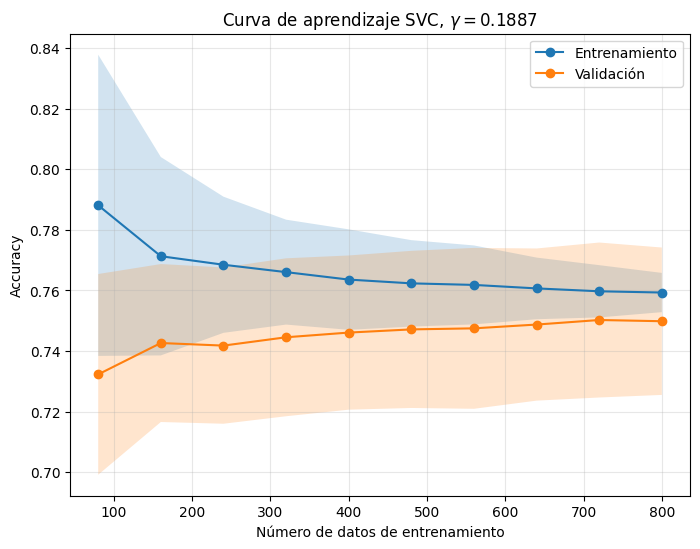

In [141]:
# @title
# ============================================================
# 7. Curva de aprendizaje
# ============================================================


# Validación cruzada:
# 100 divisiones aleatorias
# 20% de los datos se usan como validación en cada división
cv = ShuffleSplit(
    n_splits=100,
    test_size=0.20,
    random_state=123
)

# Tamaños del conjunto de entrenamiento que se van a probar
train_sizes = np.linspace(
    0.1,
    1.0,
    10
)

# Calcular curva de aprendizaje
tamanos, score_train, score_val = learning_curve(
    clf,
    datos,
    identificador,
    train_sizes=train_sizes,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# ============================================================
# Promedios y desviaciones estándar
# ============================================================

train_mean = np.mean(
    score_train,
    axis=1
)

train_std = np.std(
    score_train,
    axis=1
)

val_mean = np.mean(
    score_val,
    axis=1
)

val_std = np.std(
    score_val,
    axis=1
)


# ============================================================
# Graficar
# ============================================================

plt.figure(figsize=(8, 6))

# Accuracy de entrenamiento
plt.plot(
    tamanos,
    train_mean,
    marker="o",
    label="Entrenamiento"
)

# Región de incertidumbre entrenamiento
plt.fill_between(
    tamanos,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

# Accuracy de validación
plt.plot(
    tamanos,
    val_mean,
    marker="o",
    label="Validación"
)

# Región de incertidumbre validación
plt.fill_between(
    tamanos,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Número de datos de entrenamiento")
plt.ylabel("Accuracy")

plt.title(
    rf"Curva de aprendizaje SVC, $\gamma={mejor_gamma:.4f}$"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

Este es el modelo optimo para mis datos

#Overfitting

Accuracy entrenamiento: 0.985
Accuracy prueba: 0.665
Diferencia: 0.31999999999999995


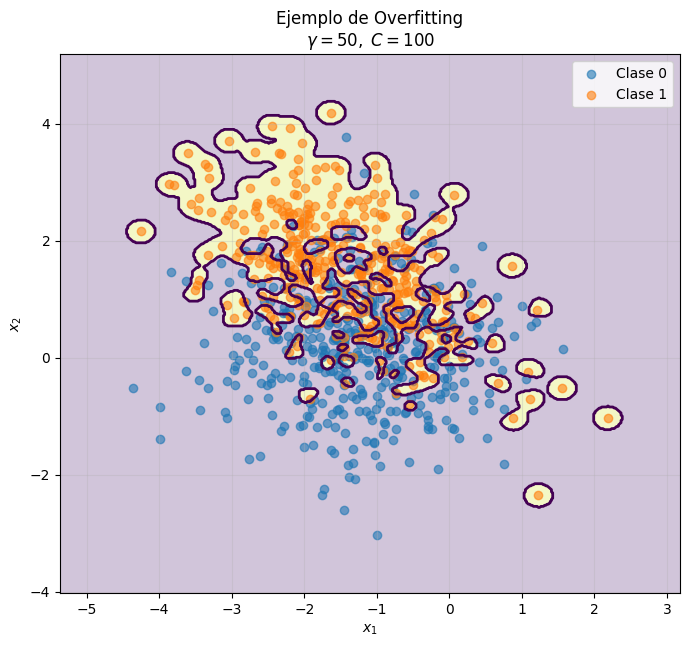

In [142]:
# @title



# ============================================================
# 1. Modelo deliberadamente complejo
# ============================================================

modelo_overfitting = SVC(
    kernel="rbf",
    gamma=50,     # gamma grande -> influencia muy local
    C=100         # C grande -> penaliza mucho los errores
)


# ============================================================
# 2. Entrenamiento
# ============================================================

modelo_overfitting.fit(
    datos_train,
    identificador_train
)


# ============================================================
# 3. Accuracy entrenamiento y prueba
# ============================================================

accuracy_train = modelo_overfitting.score(
    datos_train,
    identificador_train
)

accuracy_test = modelo_overfitting.score(
    datos_test,
    identificador_test
)


print(
    "Accuracy entrenamiento:",
    accuracy_train
)

print(
    "Accuracy prueba:",
    accuracy_test
)

print(
    "Diferencia:",
    accuracy_train - accuracy_test
)


# ============================================================
# 4. Crear malla
# ============================================================

x_min = datos[:, 0].min() - 1
x_max = datos[:, 0].max() + 1

y_min = datos[:, 1].min() - 1
y_max = datos[:, 1].max() + 1


xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)


puntos_malla = np.c_[
    xx.ravel(),
    yy.ravel()
]


# ============================================================
# 5. Clasificar toda la malla
# ============================================================

Z = modelo_overfitting.predict(
    puntos_malla
)

Z = Z.reshape(xx.shape)


# ============================================================
# 6. Graficar frontera
# ============================================================

plt.figure(figsize=(8, 7))


# Regiones de clasificación
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25
)


# Frontera
plt.contour(
    xx,
    yy,
    Z,
    levels=[0.5],
    linewidths=2
)


# Clase 0
plt.scatter(
    datos_train[
        identificador_train == 0, 0
    ],
    datos_train[
        identificador_train == 0, 1
    ],
    alpha=0.6,
    label="Clase 0"
)


# Clase 1
plt.scatter(
    datos_train[
        identificador_train == 1, 0
    ],
    datos_train[
        identificador_train == 1, 1
    ],
    alpha=0.6,
    label="Clase 1"
)


plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")

plt.title(
    r"Ejemplo de Overfitting"
    + "\n"
    + r"$\gamma=50,\; C=100$"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

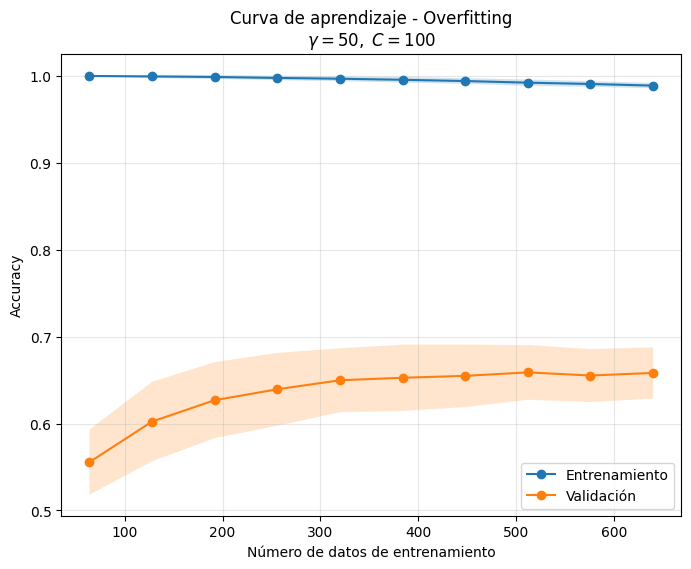

In [143]:
# @title
# ============================================================
# 7. Curva de aprendizaje del modelo con Overfitting
# ============================================================


# Validación cruzada interna sobre los datos de entrenamiento
cv = ShuffleSplit(
    n_splits=100,
    test_size=0.20,
    random_state=123
)

# Diferentes cantidades de datos de entrenamiento
train_sizes = np.linspace(
    0.1,
    1.0,
    10
)

# ============================================================
# Calcular curva de aprendizaje
# ============================================================

tamanos, score_train, score_val = learning_curve(
    modelo_overfitting,
    datos_train,
    identificador_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)


# ============================================================
# Promedios
# ============================================================

train_mean = np.mean(
    score_train,
    axis=1
)

train_std = np.std(
    score_train,
    axis=1
)

val_mean = np.mean(
    score_val,
    axis=1
)

val_std = np.std(
    score_val,
    axis=1
)


# ============================================================
# Graficar curva de aprendizaje
# ============================================================

plt.figure(figsize=(8, 6))


# Curva de entrenamiento
plt.plot(
    tamanos,
    train_mean,
    marker="o",
    label="Entrenamiento"
)

plt.fill_between(
    tamanos,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)


# Curva de validación
plt.plot(
    tamanos,
    val_mean,
    marker="o",
    label="Validación"
)

plt.fill_between(
    tamanos,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)


plt.xlabel("Número de datos de entrenamiento")
plt.ylabel("Accuracy")

plt.title(
    r"Curva de aprendizaje - Overfitting"
    + "\n"
    + r"$\gamma=50,\; C=100$"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

Tengo muy presicion pero pierdo mucho poder de prediccion

# Underfitting

Accuracy entrenamiento: 0.74875
Accuracy prueba: 0.735
Diferencia: 0.01375000000000004


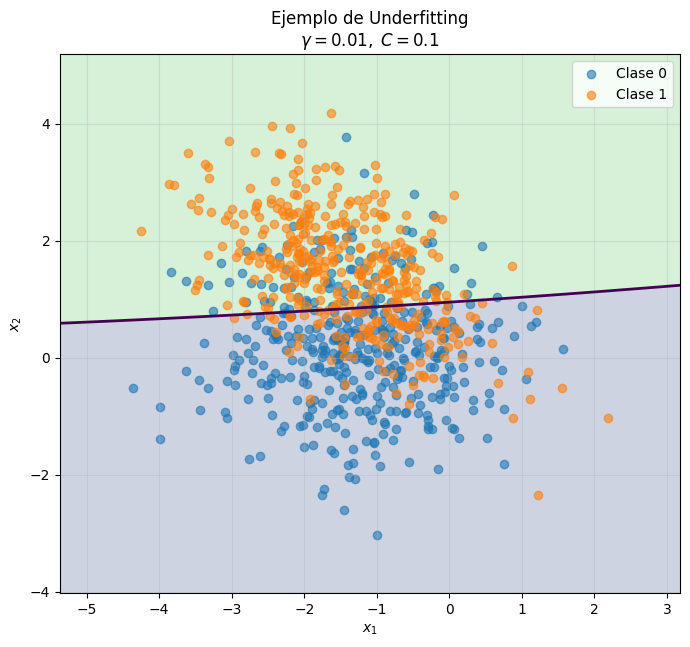

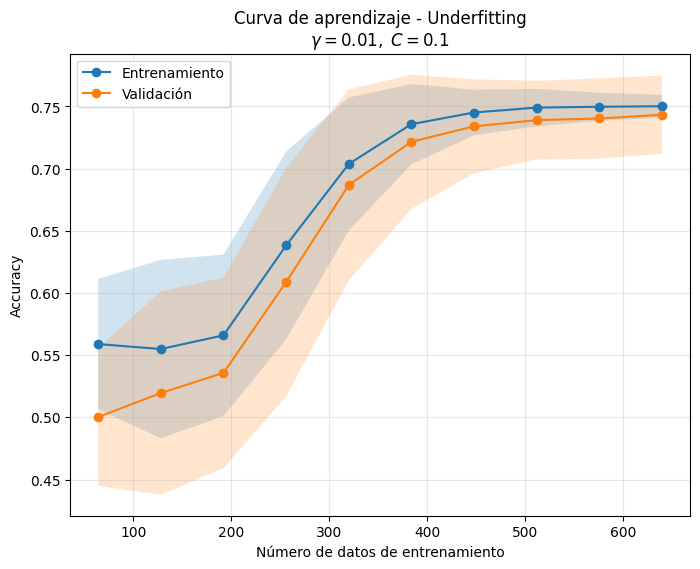

In [144]:
# @title



# ============================================================
# 1. Modelo deliberadamente simple
# ============================================================

modelo_underfitting = SVC(
    kernel="rbf",
    gamma=0.01,   # gamma pequeño -> frontera muy suave
    C=0.1         # C pequeño -> mayor tolerancia a errores
)


# ============================================================
# 2. Entrenamiento
# ============================================================

modelo_underfitting.fit(
    datos_train,
    identificador_train
)


# ============================================================
# 3. Accuracy entrenamiento y prueba
# ============================================================

accuracy_train = modelo_underfitting.score(
    datos_train,
    identificador_train
)

accuracy_test = modelo_underfitting.score(
    datos_test,
    identificador_test
)


print("Accuracy entrenamiento:", accuracy_train)
print("Accuracy prueba:", accuracy_test)

print(
    "Diferencia:",
    accuracy_train - accuracy_test
)


# ============================================================
# 4. Crear malla
# ============================================================

x_min = datos[:, 0].min() - 1
x_max = datos[:, 0].max() + 1

y_min = datos[:, 1].min() - 1
y_max = datos[:, 1].max() + 1


xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)


puntos_malla = np.c_[
    xx.ravel(),
    yy.ravel()
]


# ============================================================
# 5. Predicción sobre la malla
# ============================================================

Z_pred = modelo_underfitting.predict(
    puntos_malla
)

Z_pred = Z_pred.reshape(xx.shape)


# ============================================================
# 6. Función de decisión
# ============================================================

Z_decision = modelo_underfitting.decision_function(
    puntos_malla
)

Z_decision = Z_decision.reshape(xx.shape)


# ============================================================
# 7. Graficar frontera
# ============================================================

plt.figure(figsize=(8, 7))


# Regiones de clasificación
plt.contourf(
    xx,
    yy,
    Z_pred,
    levels=[-0.5, 0.5, 1.5],
    alpha=0.25
)


# Frontera real del SVC
plt.contour(
    xx,
    yy,
    Z_decision,
    levels=[0],
    linewidths=2
)


# Clase 0
plt.scatter(
    datos_train[
        identificador_train == 0, 0
    ],
    datos_train[
        identificador_train == 0, 1
    ],
    alpha=0.6,
    label="Clase 0"
)


# Clase 1
plt.scatter(
    datos_train[
        identificador_train == 1, 0
    ],
    datos_train[
        identificador_train == 1, 1
    ],
    alpha=0.6,
    label="Clase 1"
)


plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")

plt.title(
    r"Ejemplo de Underfitting"
    + "\n"
    + r"$\gamma=0.01,\;C=0.1$"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()


# ============================================================
# 8. Curva de aprendizaje
# ============================================================

cv = ShuffleSplit(
    n_splits=100,
    test_size=0.20,
    random_state=123
)


train_sizes = np.linspace(
    0.1,
    1.0,
    10
)


tamanos, score_train, score_val = learning_curve(
    modelo_underfitting,
    datos_train,
    identificador_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)


# ============================================================
# 9. Promedios y desviaciones
# ============================================================

train_mean = np.mean(
    score_train,
    axis=1
)

train_std = np.std(
    score_train,
    axis=1
)

val_mean = np.mean(
    score_val,
    axis=1
)

val_std = np.std(
    score_val,
    axis=1
)


# ============================================================
# 10. Graficar curva de aprendizaje
# ============================================================

plt.figure(figsize=(8, 6))


# Entrenamiento
plt.plot(
    tamanos,
    train_mean,
    marker="o",
    label="Entrenamiento"
)

plt.fill_between(
    tamanos,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)


# Validación
plt.plot(
    tamanos,
    val_mean,
    marker="o",
    label="Validación"
)

plt.fill_between(
    tamanos,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)


plt.xlabel("Número de datos de entrenamiento")
plt.ylabel("Accuracy")

plt.title(
    r"Curva de aprendizaje - Underfitting"
    + "\n"
    + r"$\gamma=0.01,\;C=0.1$"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

Mi modelo solo logra funcionar bien hasta cierto tope, hasta que llega a un limite donde por mas que aumente mis datos, mi modelo no mejora.